# Autostep in a network: keeping distractor connections quiet

A two-layer LTU network is trained with Autostep after we wire in connections we know are useless
(*distractors*). We want Autostep to leave them alone: their step-sizes should shrink over learning and their
weights should stay near 0, at no cost in loss.

**Problem.** Stationary 2-task multi-GEOFF. Each task is an independent teacher with 20 inputs ~ U(-1, 1),
10 zero-threshold LTUs and 10 outputs (each a $\pm c$ readout of the LTUs, plus $N(0, 1)$ noise). The targets have a
nonzero mean. Training is online, one fresh sample per step.

**Network.** 40 inputs → 10 LTU hidden units (5 per task) → 20 linear outputs. An LTU is a step function forward and
a sigmoid derivative backward. Each layer has a bias, a constant-1 input. The connectivity is fixed: every hidden
unit reads all of its own task's inputs and feeds all of its own task's outputs. On top of that comes one kind of
distractor, each in its own problem: in the **output-distractor problem**, even hidden units also feed all of the
other task's outputs (50 distractors); in the **input-distractor problem**, odd hidden units also read all of the
other task's inputs (100 distractors). The two kinds are kept apart because, together, each can learn to cancel the
cross-task noise the other injects, so neither would be useless. Question 3 puts them back together, once both fixes
keep them near 0.

**Learner.** Autostep, treating each layer as its own linear problem (each weight is normalized by the squared value
of its source unit), on the loss $\frac{1}{2}\|\hat{y} - y\|^2$. Every step-size starts at $10^{-7}$. Input weights
start LeCun uniform; output weights and biases start at 0.

**Success**, on the distractors a section is about, pooled over 30 seeds:
1. the excess MSE (above the noise floor) over the last 10% of training is at most 1% above the baseline's,
2. the median and 90th percentile of $|w|$ stay below $10^{-4}$ throughout training: the spread a weight reaches after
   a pure random walk over the 1M steps at the initial step-size, with unit-variance gradients
   ($\sqrt{10^6} \cdot 10^{-7}$),
3. the mean and 90th percentile of $\beta = \ln(\text{step-size})$ end below their initial value (the 90th percentile
   is a soft constraint). The mean is taken over $\beta$, not the step-size, so step-sizes that merely spread out
   symmetrically do not count as a rise.

Every distractor statistic is recorded after step 1, then once per window of training: $\beta$ at the window's end,
and $|w|$ at its peak within the window, so short spikes in the weights are not missed. ($\beta$ jitters, so its
peak would sit above its actual value.)

In [1]:
from typing import NamedTuple

import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from phd.jax_core.models import ltu
from phd.jax_core.optimizers.idbd import IDBDState, optax_idbd
from phd.jax_core.tasks.multi_geoff import MultiGEOFFTask
from phd.jax_core.utils import stack_pytrees

sns.set_theme('notebook', 'white')
%matplotlib inline

/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/home/edan/miniconda3/envs/jax/lib/python3.10/site-packages/pydantic/_internal/_generate_schema.py:2274: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an 

In [2]:
# --- Problem ---
N_TASKS = 2
N_INPUTS_PER_TASK = 20
N_TEACHER_LTUS_PER_TASK = 10
N_OUTPUTS_PER_TASK = 10
NOISE_STD = 1.0

# --- Network ---
N_HIDDEN_PER_TASK = 5

# --- Autostep ---
INIT_STEP_SIZE = 1e-8
META_STEP_SIZE = 0.02
TAU = 1e4
NORM_EPS = 1e-4                      # variance floor of the normalized hidden units

# --- Sweeps ---
BIAS_STEP_SIZES = (2 ** -6, 2 ** -4, 2 ** -2)
EMA_RATES = (1e-2, 1e-3, 1e-4)
KAPPAS = (1e-3, 1e-4, 1e-5)

# --- Training ---
NUM_STEPS = 1_000_000
N_SEEDS = 30
N_WINDOWS = 250                      # each window records its mean loss and every distractor's peak

# --- Success criteria ---
FINAL_FRACTION = 0.1                 # the loss is compared over the last 10% of training ...
LOSS_TOLERANCE = 0.01                # ... and may be at most 1% above the baseline's
WEIGHT_THRESHOLD = 1e-4             # the spread of a weight after a pure random walk over training at the initial
                                    # step-size with unit-variance gradients: sqrt(NUM_STEPS) * INIT_STEP_SIZE = 1e-4

In [3]:
LAYERS = ('w1', 'w2')
N_HIDDEN = N_TASKS * N_HIDDEN_PER_TASK
N_OUTPUTS = N_TASKS * N_OUTPUTS_PER_TASK

input_task = np.repeat(np.arange(N_TASKS), N_INPUTS_PER_TASK)
hidden_task = np.repeat(np.arange(N_TASKS), N_HIDDEN_PER_TASK)
output_task = np.repeat(np.arange(N_TASKS), N_OUTPUTS_PER_TASK)
reads_other_inputs = np.arange(N_HIDDEN) % 2 == 1        # odd hidden units
feeds_other_outputs = ~reads_other_inputs                 # even hidden units


def with_bias_column(mask, bias):
    # The last column of each weight matrix reads the constant-1 input.
    return np.concatenate([mask, np.full((mask.shape[0], 1), bias)], axis=1)


# Masks are shaped like the weight matrices: w1 is (hidden, inputs + 1), w2 is (outputs, hidden + 1).
same_task = {'w1': hidden_task[:, None] == input_task[None, :],
             'w2': output_task[:, None] == hidden_task[None, :]}
DISTRACTORS = {'w1': with_bias_column(~same_task['w1'] & reads_other_inputs[:, None], False),
               'w2': with_bias_column(~same_task['w2'] & feeds_other_outputs[None, :], False)}
BLOCK_SPARSE = {k: with_bias_column(m, True) for k, m in same_task.items()}
USEFUL = {k: with_bias_column(m, False) for k, m in same_task.items()}     # BLOCK_SPARSE without the biases

# Each problem is block-sparse plus one kind of distractor ('both' has both, for Question 3); 'none' has none.
DISTRACTOR_LAYER = {'output': 'w2', 'input': 'w1'}
MASKS = {'none': BLOCK_SPARSE,
         'output': {'w1': BLOCK_SPARSE['w1'], 'w2': BLOCK_SPARSE['w2'] | DISTRACTORS['w2']},
         'input': {'w1': BLOCK_SPARSE['w1'] | DISTRACTORS['w1'], 'w2': BLOCK_SPARSE['w2']},
         'both': {k: BLOCK_SPARSE[k] | DISTRACTORS[k] for k in LAYERS}}
PROBLEM_NAMES = {'output': 'output-distractor problem', 'input': 'input-distractor problem',
                 'both': 'problem with both kinds of distractor'}

for k in LAYERS:
    print(f'{k}: {BLOCK_SPARSE[k][:, :-1].sum()} useful, {DISTRACTORS[k].sum()} distractors, '
          f'{BLOCK_SPARSE[k].shape[0]} biases')

w1: 200 useful, 100 distractors, 10 biases
w2: 100 useful, 50 distractors, 20 biases


## Learner

In [4]:
OPTIMIZER = optax_idbd(meta_lr=META_STEP_SIZE, init_lr=INIT_STEP_SIZE, autostep=True, tau=TAU,
                       version='squared_inputs')


class Method(eqx.Module):
    # What differs between runs. The float fields can be swept (they are vmapped); the rest are fixed per run.
    problem: str = eqx.field(static=True)                       # which distractors the network has: a key of MASKS
    bias_step_size: float = INIT_STEP_SIZE                      # initial step-size of every bias
    ema_rate: float = 1e-3                                      # rate of the hidden units' running mean and variance
    hidden_signal: str = eqx.field(static=True, default='raw')  # what a hidden unit sends: 'raw', 'centered' or 'normalized'
    center_backward: bool = eqx.field(static=True, default=False)  # with 'centered', also center the backward pass
    kappa: float = 0.0                                          # step-size decay (Question 4): every beta also falls by META_STEP_SIZE * kappa per step
    w1_init: str = eqx.field(static=True, default='lecun')      # 'lecun', or 'step_size' for U(-INIT_STEP_SIZE, INIT_STEP_SIZE)

    @property
    def masks(self):
        return MASKS[self.problem]


class Learner(NamedTuple):
    w: dict                   # {'w1': ..., 'w2': ...}; masked-out weights stay at exactly 0 (their gradient is 0)
    opt: IDBDState
    hidden_mean: jax.Array    # each hidden unit's running mean and variance; every run tracks them, but only the
    hidden_var: jax.Array     # centered and normalized signals use them
    hidden_slope: jax.Array   # running mean of sigma'(z) x, each hidden unit's derivative w.r.t. each input weight;
                              # only the centered backward pass uses it


def init_learner(method, key):
    masks = method.masks
    # Input weights: LeCun uniform over each unit's inputs, or uniform on +-INIT_STEP_SIZE. Both scale the same draw.
    fan_in = masks['w1'][:, :-1].sum(1, keepdims=True)
    bound = INIT_STEP_SIZE if method.w1_init == 'step_size' else np.sqrt(3.0 / fan_in)
    w1 = jax.random.uniform(key, masks['w1'].shape, minval=-1.0, maxval=1.0) * bound * masks['w1']
    w = {'w1': w1.at[:, -1].set(0.0), 'w2': jnp.zeros(masks['w2'].shape)}

    opt = OPTIMIZER.init(w)
    opt = opt._replace(beta={k: b.at[:, -1].set(jnp.log(method.bias_step_size)) for k, b in opt.beta.items()})
    # A zero-threshold LTU with symmetric inputs fires with probability 1/2, so these start out exact. The slope starts
    # at sigma'(0) E[x]: 0 for the zero-mean inputs, 1/4 for the bias.
    return Learner(w, opt, jnp.full(N_HIDDEN, 0.5), jnp.full(N_HIDDEN, 0.25),
                   jnp.zeros(masks['w1'].shape).at[:, -1].set(0.25))


def forward(w, x, learner, method):
    # Returns the prediction, each weight's source values (what Autostep normalizes by), and the new hidden stats.
    masks = method.masks
    x = jnp.append(x, 1.0)
    w1 = w['w1'] * masks['w1']
    z = w1 @ x
    h = ltu(z)

    # Welford-style EMA of each unit's mean and variance, updated with this sample before it is used. No gradient
    # flows through them.
    delta = jax.lax.stop_gradient(h) - learner.hidden_mean
    mean = learner.hidden_mean + method.ema_rate * delta
    var = (1.0 - method.ema_rate) * (learner.hidden_var + method.ema_rate * delta ** 2)
    sigma_prime = jax.lax.stop_gradient(jax.nn.sigmoid(z) * (1.0 - jax.nn.sigmoid(z)))     # the LTU's surrogate slope
    slope = learner.hidden_slope + method.ema_rate * (sigma_prime[:, None] * x[None, :] - learner.hidden_slope)
    if method.hidden_signal == 'centered':
        h = h - mean
        if method.center_backward:
            # The gradient of h - E[h]: each weight's derivative becomes sigma'(z) x - slope. The value is unchanged.
            correction = jnp.sum(slope * w1, axis=1)
            h = h - correction + jax.lax.stop_gradient(correction)
    elif method.hidden_signal == 'normalized':
        h = (h - mean) / jnp.sqrt(var + NORM_EPS)

    h = jnp.append(h, 1.0)
    y_hat = (w['w2'] * masks['w2']) @ h
    return y_hat, ({'w1': x[None], 'w2': h[None]}, mean, var, slope)


def learner_step(learner, x, y, method):
    # One online Autostep update. Returns the new learner and the squared error summed over outputs.
    def loss_fn(w):
        y_hat, aux = forward(w, x, learner, method)
        return 0.5 * jnp.sum((y_hat - y) ** 2), aux

    (loss, (source_values, mean, var, slope)), grads = jax.value_and_grad(loss_fn, has_aux=True)(learner.w)
    updates, opt = OPTIMIZER.update((grads, None, source_values), learner.opt, learner.w)
    opt = opt._replace(beta={k: b - META_STEP_SIZE * method.kappa for k, b in opt.beta.items()})   # decay, from the next step
    w = {k: learner.w[k] + updates[k] for k in LAYERS}
    return Learner(w, opt, mean, var, slope), 2.0 * loss

## Training

In [5]:
def recorded_values(learner, record):
    # beta and |w| of the weights in `record` (a mask per layer), flattened per layer.
    return {k: {'beta': learner.opt.beta[k][record[k]],
                'w': jnp.abs(learner.w[k])[record[k]]} for k in LAYERS}


def train(method, key, task, record):
    # Step 1 on its own, then NUM_STEPS online steps in windows. Returns the per-output MSE of every window, and the
    # beta (log step-size) and |w| of each weight in `record` after step 1, followed by beta at the end of every window
    # and |w| at its peak within it.
    def one_step(carry, _):
        learner, task, peak = carry
        task, (x, y) = task.generate_batch(1)
        learner, sq_err = learner_step(learner, x[0], y[0], method)
        peak = jax.tree.map(jnp.maximum, peak, recorded_values(learner, record))
        return (learner, task, peak), sq_err

    def window(carry, _):
        learner, task = carry
        (learner, task, peak), sq_err = jax.lax.scan(
            one_step, (learner, task, recorded_values(learner, record)), length=NUM_STEPS // N_WINDOWS)
        end = recorded_values(learner, record)
        values = {k: {'beta': end[k]['beta'], 'w': peak[k]['w']} for k in LAYERS}
        return (learner, task), (sq_err.mean() / N_OUTPUTS, values)

    task, (x, y) = task.generate_batch(1)
    learner, _ = learner_step(init_learner(method, key), x[0], y[0], method)
    _, (mse, peaks) = jax.lax.scan(window, (learner, task), length=N_WINDOWS)
    peaks = jax.tree.map(lambda first, p: jnp.concatenate([first[None], p]), recorded_values(learner, record), peaks)
    return mse, peaks


def seeds():
    # Init keys and teachers. Seed s uses teacher s and init key s for every method, so runs are paired.
    tasks = stack_pytrees([
        MultiGEOFFTask(N_TASKS, n_features_per_task=N_INPUTS_PER_TASK, n_hidden_per_task=N_TEACHER_LTUS_PER_TASK,
                       n_outputs_per_task=N_OUTPUTS_PER_TASK, noise_std=NOISE_STD, seed=s)
        for s in range(N_SEEDS)])
    return jax.random.split(jax.random.PRNGKey(0), N_SEEDS), tasks


def run(methods, record=DISTRACTORS):
    # Train every method in `methods` ({label: Method}, all with the same static fields) on the same N_SEEDS seeds,
    # vmapped into one scan, recording the weights in `record`.
    keys, tasks = seeds()
    over_seeds = jax.vmap(lambda method, key, task: train(method, key, task, record), in_axes=(None, 0, 0))
    mse, peaks = jax.jit(jax.vmap(over_seeds, in_axes=(0, None, None)))(
        stack_pytrees(list(methods.values())), keys, tasks)
    # Per run: excess MSE (seed, window), and peaks[layer][quantity] (seed, step 1 + window, recorded weight).
    return {label: {'excess_mse': np.asarray(mse[i]) - NOISE_STD ** 2,
                    **{k: {q: np.asarray(v[i]) for q, v in peaks[k].items()} for k in LAYERS}}
            for i, label in enumerate(methods)}

## Plots and criteria

In [6]:
STEPS = 1 + np.arange(N_WINDOWS + 1) * (NUM_STEPS // N_WINDOWS)     # step 1, then the end of every window


def colors(runs):
    # The baseline in red, the references in gray, and the proposed methods in shades of blue.
    fixed = {'baseline': 'tab:red', 'no distractors': 'gray', 'centering + small init': 'gray', 'no decay': 'gray'}
    methods = [label for label in runs if label not in fixed]
    shades = dict(zip(methods, plt.cm.Blues(np.linspace(0.9, 0.5, len(methods)))))
    return [{**fixed, **shades}[label] for label in runs]


def pooled(values, center):
    # `center` (np.mean or np.median) and the 90th percentile per window, over every distractor of every seed. `values`
    # is (seed, window, distractor).
    v = values.transpose(1, 0, 2).reshape(values.shape[1], -1)
    return center(v, axis=1), np.percentile(v, 90, axis=1)


def plot_loss(runs, problem):
    plt.figure(figsize=(7, 4))
    for (label, res), color in zip(runs.items(), colors(runs)):
        mean = res['excess_mse'].mean(0)
        sem = res['excess_mse'].std(0) / np.sqrt(N_SEEDS)
        plt.plot(STEPS[1:], mean, color=color, lw=1.5, label=label)
        plt.fill_between(STEPS[1:], mean - 2 * sem, mean + 2 * sem, color=color, alpha=0.2)
    plt.yscale('log')
    plt.xlabel('step')
    plt.ylabel('excess MSE per output')
    plt.title(f'Loss on the {PROBLEM_NAMES[problem]} (mean $\\pm$ 2 SE over seeds)')
    plt.grid(alpha=0.4, which='both')
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def plot_distractors(runs, kind):
    layer = DISTRACTOR_LAYER[kind]
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    # Each panel: quantity, y label, central statistic (the mean of beta, a log, sits mid-distribution; the median of
    # |w| does too, where its mean would be pulled up by the largest weights), reference line, its label, y scale, and
    # the lowest value shown (an order of magnitude below the initial step-size; anything smaller is just "small").
    panels = [('beta', '$\\beta$ = ln(step-size)', ('mean', np.mean), np.log(INIT_STEP_SIZE), 'initial $\\beta$',
               'linear', np.log(INIT_STEP_SIZE / 10)),
              ('w', '$|w|$', ('median', np.median), WEIGHT_THRESHOLD, 'threshold', 'log', INIT_STEP_SIZE / 10)]
    for ax, (quantity, ylabel, (center_name, center), ref, ref_label, yscale, bottom) in zip(axes, panels):
        for (label, res), color in zip(runs.items(), colors(runs)):
            mid, p90 = (np.maximum(s, bottom) for s in pooled(res[layer][quantity], center))   # drawn on the floor once below it
            ax.plot(STEPS, mid, color=color, lw=1.5, label=label)
            ax.plot(STEPS, p90, color=color, lw=1.5, ls='--')
        ax.axhline(ref, color='black', lw=1.5, label=ref_label)
        ax.plot([], [], color='gray', lw=1.5, label=center_name)
        ax.plot([], [], color='gray', lw=1.5, ls='--', label='90th percentile')
        ax.set_yscale(yscale)
        ax.set_ylim(bottom=bottom)
        ax.set_xlabel('step')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.4, which='both')
        ax.legend(fontsize=8)
    fig.suptitle(f'{kind.capitalize()} distractors (step 1, then per window: $\\beta$ at its end, $|w|$ at its peak; pooled over seeds)')
    fig.tight_layout()
    plt.show()


def report(runs, kind):
    # The three success criteria on the `kind` ('output' or 'input') distractors: loss over the last FINAL_FRACTION of
    # training (against runs['baseline']), |w| at its worst window, and beta (log step-size) in the last window.
    layer = DISTRACTOR_LAYER[kind]
    final = slice(-round(N_WINDOWS * FINAL_FRACTION), None)
    baseline_loss = runs['baseline']['excess_mse'][:, final].mean()
    mark = lambda ok: '✓' if ok else '✗'
    width = max(map(len, runs))
    print(f'{kind} distractors (initial beta {np.log(INIT_STEP_SIZE):.1f})')
    for label, res in runs.items():
        loss = res['excess_mse'][:, final].mean()
        w_median, w_p90 = (s.max() for s in pooled(res[layer]['w'], np.median))
        b_mean, b_p90 = (s[-1] for s in pooled(res[layer]['beta'], np.mean))
        print(f'  {label:<{width}}   '
              f'excess MSE {loss:.4f} ({loss / baseline_loss - 1:+.1%}) '
              f'{mark(loss <= (1 + LOSS_TOLERANCE) * baseline_loss)}   '
              f'max |w|: median {w_median:.1e} {mark(w_median <= WEIGHT_THRESHOLD)}, '
              f'p90 {w_p90:.1e} {mark(w_p90 <= WEIGHT_THRESHOLD)}   '
              f'final beta: mean {b_mean:.1f} {mark(b_mean < np.log(INIT_STEP_SIZE))}, '
              f'p90 {b_p90:.1f} {mark(b_p90 < np.log(INIT_STEP_SIZE))}')

## Baseline

Standard Autostep as described at the top, on each problem. The *no distractors* reference is the same network
without any distractors: the loss we would get if they cost nothing.

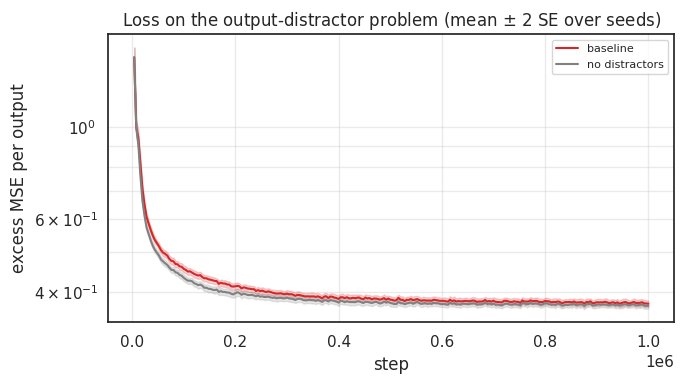

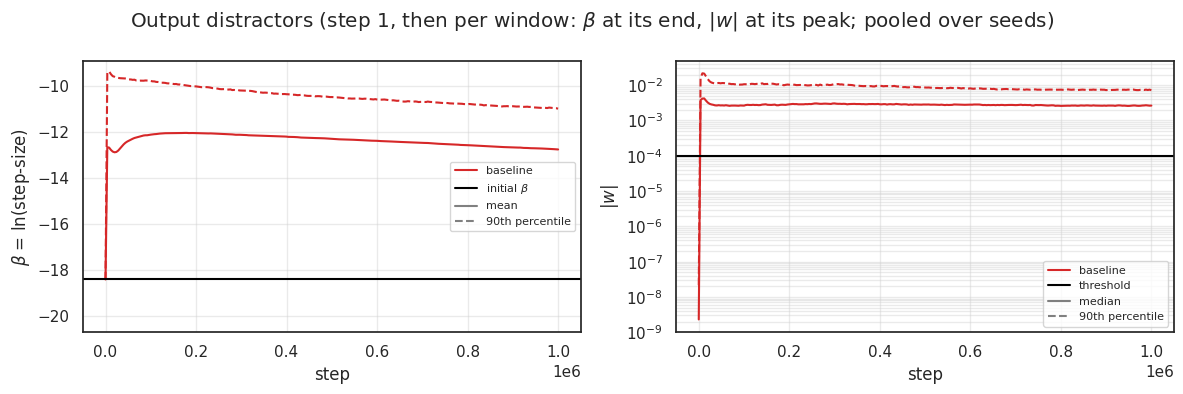

output distractors (initial beta -18.4)
  baseline   excess MSE 0.3774 (+0.0%) ✓   max |w|: median 4.2e-03 ✗, p90 2.2e-02 ✗   final beta: mean -12.7 ✗, p90 -11.0 ✗


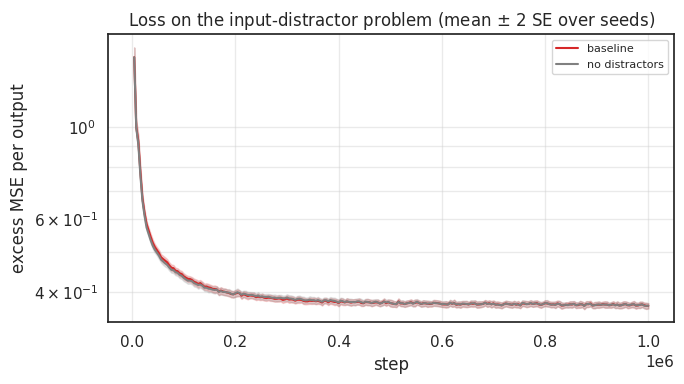

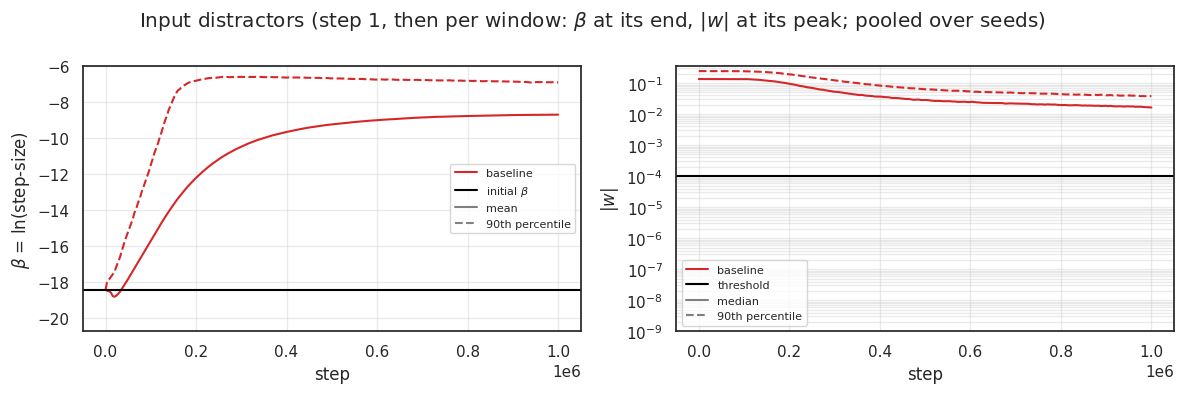

input distractors (initial beta -18.4)
  baseline   excess MSE 0.3728 (+0.0%) ✓   max |w|: median 1.4e-01 ✗, p90 2.4e-01 ✗   final beta: mean -8.7 ✗, p90 -6.9 ✗


In [7]:
baseline = {problem: run({'baseline': Method(problem=problem)})['baseline'] for problem in DISTRACTOR_LAYER}
reference = run({'no distractors': Method(problem='none')})

for problem in DISTRACTOR_LAYER:
    plot_loss({'baseline': baseline[problem], **reference}, problem)
    plot_distractors({'baseline': baseline[problem]}, problem)
    report({'baseline': baseline[problem]}, problem)

## Question 1: distractors from non-zero-mean hidden units acting as biases

An LTU outputs 0 or 1, so every hidden unit has a positive mean. While an output still has a mean error, an
output distractor gets a consistently signed gradient and acts as a partial bias: its weight and step-size grow,
and take a long time to come back down. Each method below is compared with the baseline on the
**output-distractor problem**.

### 1a. Fast biases

The biases of both layers start at a much larger step-size than every other weight, so they can absorb the
targets' mean before the distractors do.

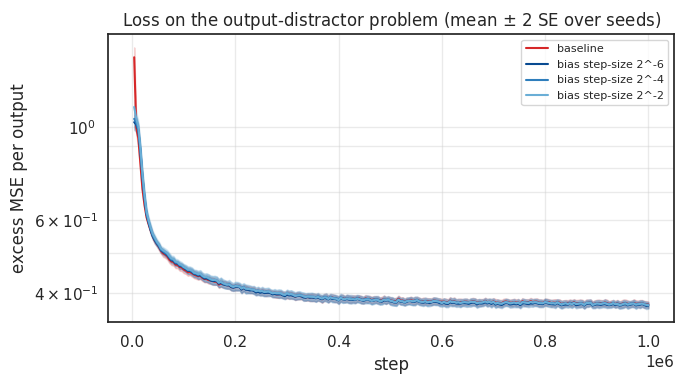

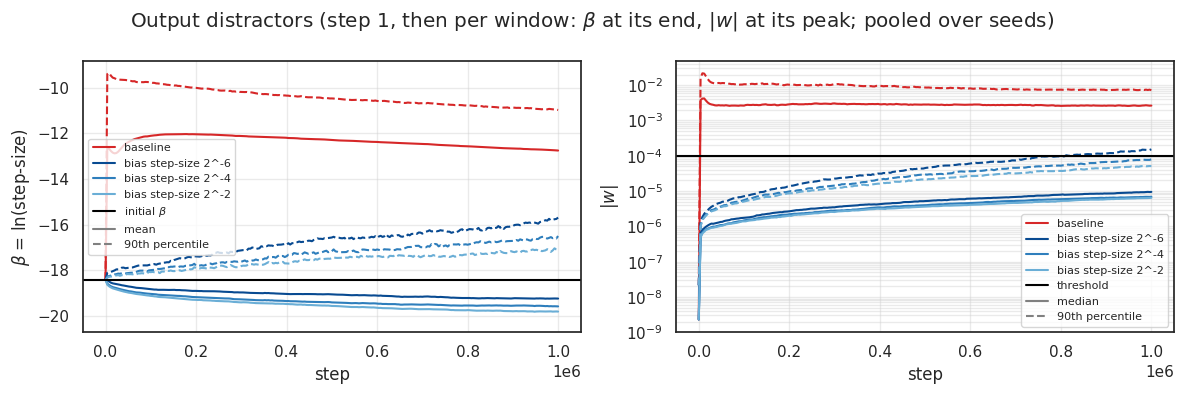

output distractors (initial beta -18.4)
  baseline              excess MSE 0.3774 (+0.0%) ✓   max |w|: median 4.2e-03 ✗, p90 2.2e-02 ✗   final beta: mean -12.7 ✗, p90 -11.0 ✗
  bias step-size 2^-6   excess MSE 0.3749 (-0.7%) ✓   max |w|: median 9.5e-06 ✓, p90 1.5e-04 ✗   final beta: mean -19.2 ✓, p90 -15.7 ✗
  bias step-size 2^-4   excess MSE 0.3771 (-0.1%) ✓   max |w|: median 6.9e-06 ✓, p90 7.9e-05 ✓   final beta: mean -19.6 ✓, p90 -16.5 ✗
  bias step-size 2^-2   excess MSE 0.3763 (-0.3%) ✓   max |w|: median 6.4e-06 ✓, p90 5.1e-05 ✓   final beta: mean -19.8 ✓, p90 -17.1 ✗


In [8]:
fast_bias = run({f'bias step-size 2^{np.log2(a):.0f}': Method(problem='output', bias_step_size=a)
                 for a in BIAS_STEP_SIZES})

runs = {'baseline': baseline['output'], **fast_bias}
plot_loss(runs, 'output')
plot_distractors(runs, 'output')
report(runs, 'output')

### 1b. Normalized hidden units

Each hidden unit sends $(h - m) / \sqrt{s + \epsilon}$ instead of $h$, where $m$ and $s$ are its running mean and
variance (a Welford-style EMA at rate $\beta$, starting at $m = 1/2$, $s = 1/4$).

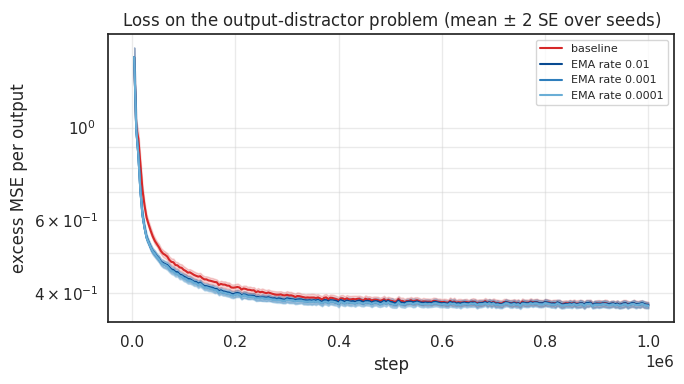

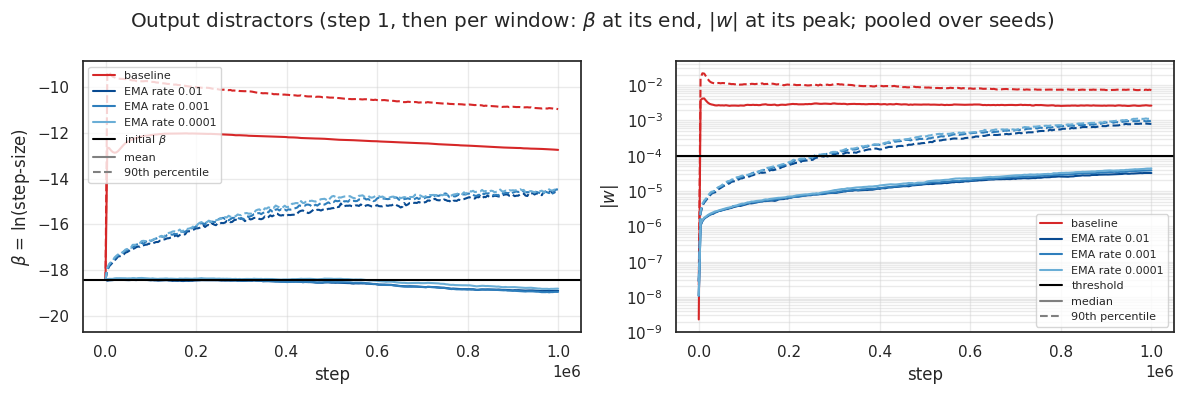

output distractors (initial beta -18.4)
  baseline          excess MSE 0.3774 (+0.0%) ✓   max |w|: median 4.2e-03 ✗, p90 2.2e-02 ✗   final beta: mean -12.7 ✗, p90 -11.0 ✗
  EMA rate 0.01     excess MSE 0.3775 (+0.0%) ✓   max |w|: median 3.3e-05 ✓, p90 8.2e-04 ✗   final beta: mean -18.9 ✓, p90 -14.5 ✗
  EMA rate 0.001    excess MSE 0.3758 (-0.4%) ✓   max |w|: median 3.9e-05 ✓, p90 9.9e-04 ✗   final beta: mean -19.0 ✓, p90 -14.5 ✗
  EMA rate 0.0001   excess MSE 0.3756 (-0.5%) ✓   max |w|: median 4.4e-05 ✓, p90 1.1e-03 ✗   final beta: mean -18.8 ✓, p90 -14.4 ✗


In [9]:
normalized = run({f'EMA rate {r:g}': Method(problem='output', hidden_signal='normalized', ema_rate=r)
                   for r in EMA_RATES})

runs = {'baseline': baseline['output'], **normalized}
plot_loss(runs, 'output')
plot_distractors(runs, 'output')
report(runs, 'output')

### 1c. Centered hidden units

Each hidden unit sends $h - m$ instead of $h$, where $m$ is its running mean firing rate (same EMA as in 1b).

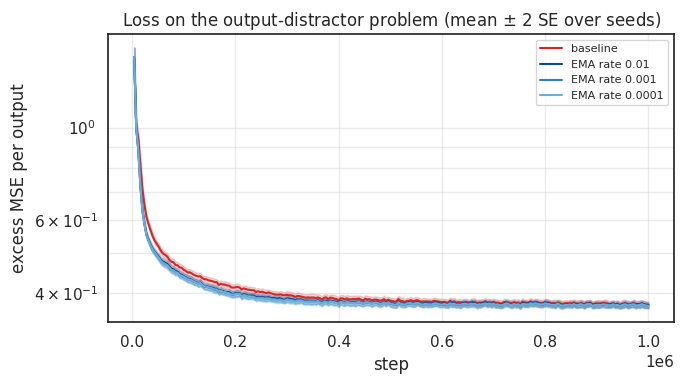

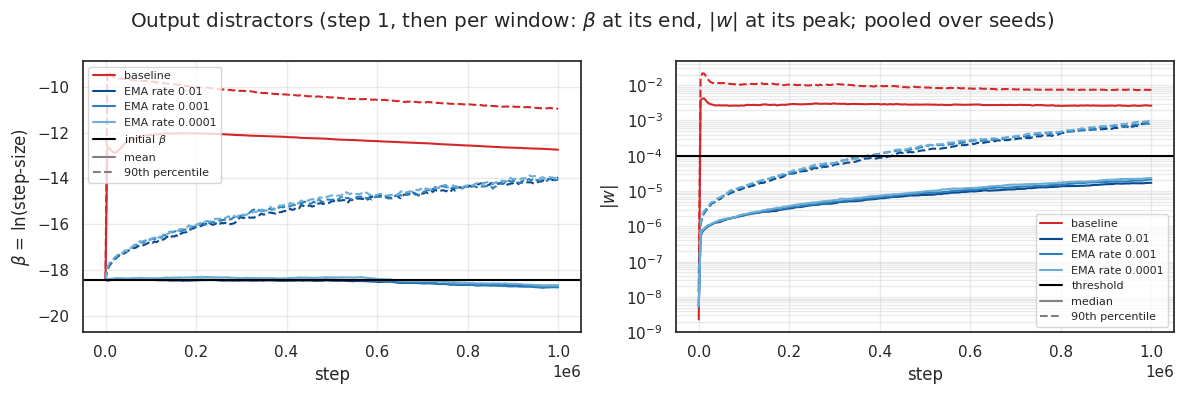

output distractors (initial beta -18.4)
  baseline          excess MSE 0.3774 (+0.0%) ✓   max |w|: median 4.2e-03 ✗, p90 2.2e-02 ✗   final beta: mean -12.7 ✗, p90 -11.0 ✗
  EMA rate 0.01     excess MSE 0.3766 (-0.2%) ✓   max |w|: median 1.7e-05 ✓, p90 8.5e-04 ✗   final beta: mean -18.7 ✓, p90 -14.0 ✗
  EMA rate 0.001    excess MSE 0.3745 (-0.8%) ✓   max |w|: median 2.1e-05 ✓, p90 8.3e-04 ✗   final beta: mean -18.8 ✓, p90 -14.1 ✗
  EMA rate 0.0001   excess MSE 0.3750 (-0.6%) ✓   max |w|: median 2.4e-05 ✓, p90 1.0e-03 ✗   final beta: mean -18.7 ✓, p90 -14.0 ✗


In [10]:
centered = run({f'EMA rate {r:g}': Method(problem='output', hidden_signal='centered', ema_rate=r)
                   for r in EMA_RATES})

runs = {'baseline': baseline['output'], **centered}
plot_loss(runs, 'output')
plot_distractors(runs, 'output')
report(runs, 'output')

## Question 2: input weights initialized off zero

With the usual fan-in initialization, an input distractor starts far from 0, so its gradient pulls it toward 0
consistently, and its step-size spikes until it gets there. Here the input weights are instead drawn from
U(−α₀, α₀), where α₀ = 10⁻⁷ is the initial step-size. The draw is the baseline's, only rescaled, so the hidden
units compute exactly the same features at step 0. Compared with the baseline on the **input-distractor problem**.

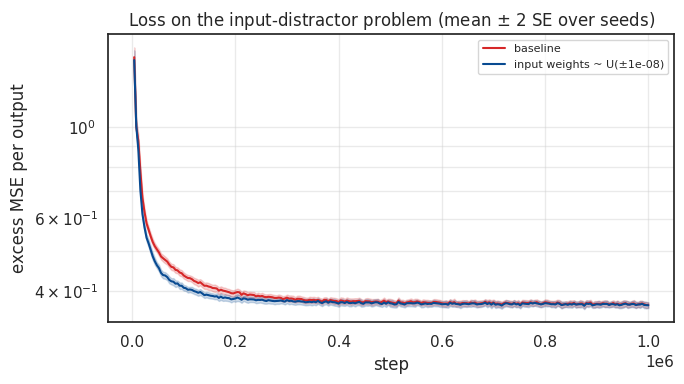

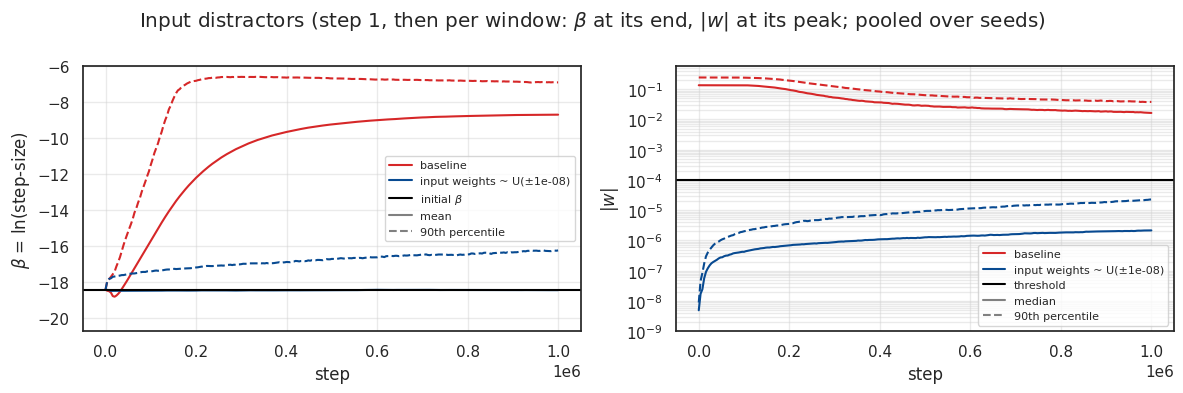

input distractors (initial beta -18.4)
  baseline                    excess MSE 0.3728 (+0.0%) ✓   max |w|: median 1.4e-01 ✗, p90 2.4e-01 ✗   final beta: mean -8.7 ✗, p90 -6.9 ✗
  input weights ~ U(±1e-08)   excess MSE 0.3718 (-0.3%) ✓   max |w|: median 2.2e-06 ✓, p90 2.3e-05 ✓   final beta: mean -18.4 ✓, p90 -16.2 ✗


In [11]:
small_init = run({f'input weights ~ U(±{INIT_STEP_SIZE:g})': Method(problem='input', w1_init='step_size')})

runs = {'baseline': baseline['input'], **small_init}
plot_loss(runs, 'input')
plot_distractors(runs, 'input')
report(runs, 'input')

## Question 3: fixing the whole network at once

Questions 1 and 2 each fixed one layer on its own problem: centering the hidden units kept the output distractors'
step-sizes from rising (1c), and starting the input weights at U(−α₀, α₀) kept the input distractors' step-sizes from
spiking (Question 2). If both fixes carry over, using them together on the problem with both kinds of distractor should
keep every distractor quiet. Biases start at α₀, like every other weight.

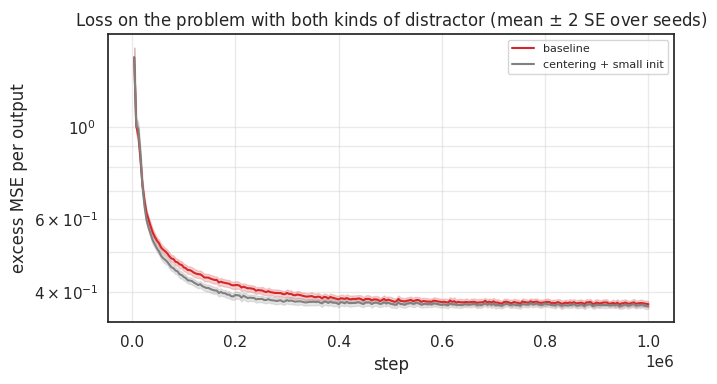

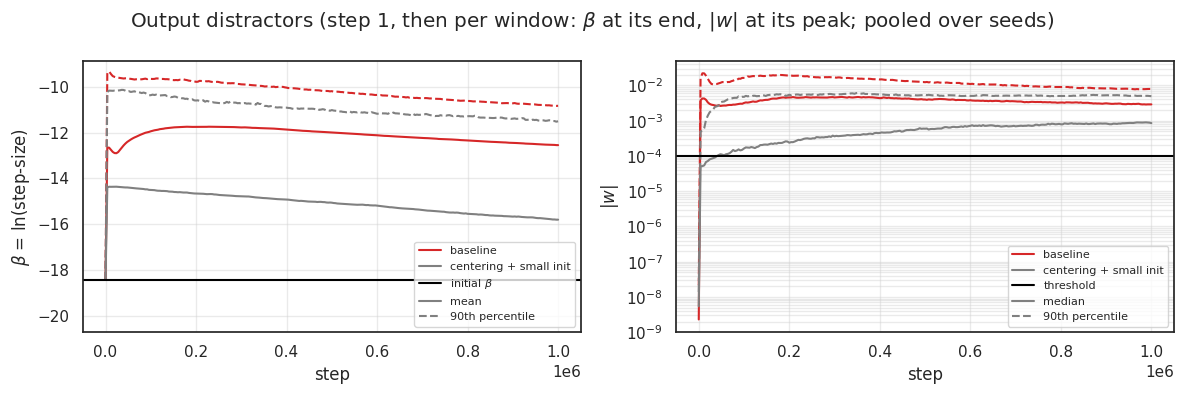

output distractors (initial beta -18.4)
  baseline                 excess MSE 0.3753 (+0.0%) ✓   max |w|: median 4.7e-03 ✗, p90 2.2e-02 ✗   final beta: mean -12.5 ✗, p90 -10.8 ✗
  centering + small init   excess MSE 0.3712 (-1.1%) ✓   max |w|: median 9.0e-04 ✗, p90 6.1e-03 ✗   final beta: mean -15.8 ✗, p90 -11.5 ✗


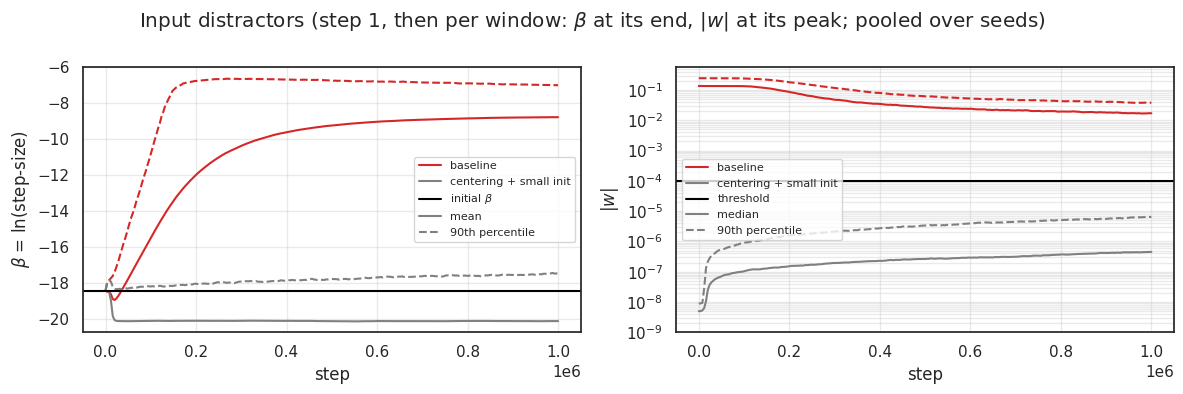

input distractors (initial beta -18.4)
  baseline                 excess MSE 0.3753 (+0.0%) ✓   max |w|: median 1.4e-01 ✗, p90 2.4e-01 ✗   final beta: mean -8.8 ✗, p90 -7.0 ✗
  centering + small init   excess MSE 0.3712 (-1.1%) ✓   max |w|: median 4.5e-07 ✓, p90 6.4e-06 ✓   final beta: mean -20.1 ✓, p90 -17.5 ✗


In [12]:
combination = dict(problem='both', hidden_signal='centered', w1_init='step_size')
both_baseline = run({'baseline': Method(problem='both')})
both_combination = run({'centering + small init': Method(**combination)})

runs = {**both_baseline, **both_combination}
plot_loss(runs, 'both')
for kind in DISTRACTOR_LAYER:
    plot_distractors(runs, kind)
    report(runs, kind)

### 3b. Why the combination fails

The output distractors' $\beta$ jumps by about 3.5 within the first few thousand steps. A random walk cannot move the
mean of $\beta$, so something pushes these step-sizes up consistently:
1. Early on, every output is wrong on average, because its bias has not yet learned the targets' mean. Backprop passes
   that error back to each hidden unit as "fire more" or "fire less", so every hidden bias moves steadily one way. With
   centering this cannot fix an output's mean (an output only sees $h - m$, and $m$ follows the firing rate), but the
   backward pass treats $m$ as a constant, so the push stays.
2. With input weights near $10^{-7}$, a unit's pre-activation is also near $10^{-7}$, so its bias soon dominates and the
   unit fires almost always or almost never. With LeCun init (1c) the pre-activations are about 0.4, and the same push
   barely moves the firing rate.
3. The firing rate moves faster than the running average $m$ can follow (it remembers about 1000 steps), so $h - m$
   carries a large mean, and the output distractors soak up the outputs' mean error just as in the baseline.

The plots follow the start of training: the output distractors' mean $\beta$, and how far the hidden units' true firing
rates (measured on 4096 fixed inputs) are from 1/2 and from $m$.

2026-10-02 19:54:51.840817: W external/xla/xla/service/gpu/autotuning/dot_search_space.cc:200] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs?Working around this by using the full hints set instead.


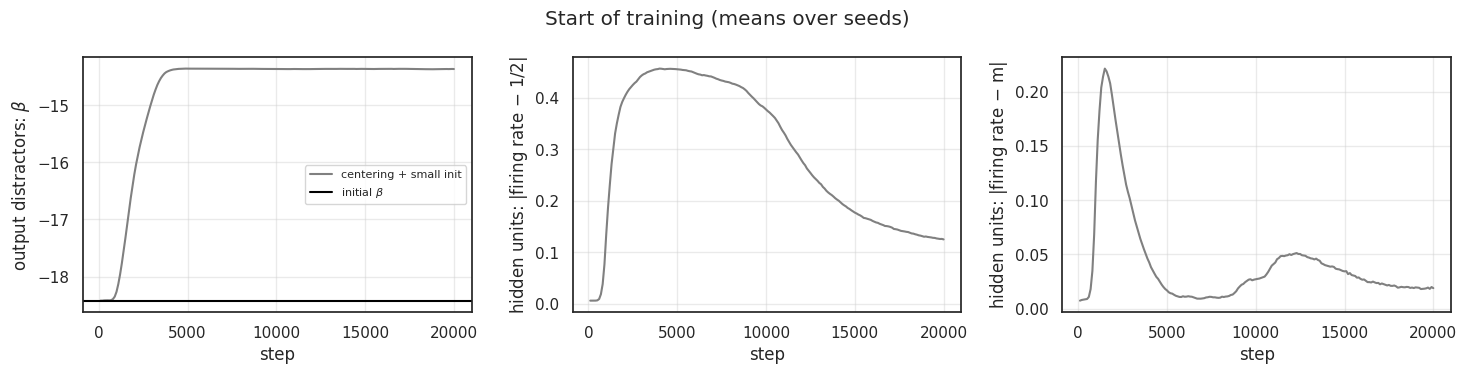

In [13]:
def early_dynamics(methods, num_steps=20_000, every=100):
    # Short runs of each method ({label: Method}). Every `every` steps, records the output distractors' beta, and each
    # hidden unit's true firing rate (on a fixed batch of probe inputs) minus 1/2 and minus its running average m.
    probe = jax.random.uniform(jax.random.PRNGKey(1), (4096, N_TASKS * N_INPUTS_PER_TASK), minval=-1.0, maxval=1.0)
    probe = jnp.concatenate([probe, jnp.ones((4096, 1))], axis=1)

    def train_short(method, key, task):
        def one_step(carry, _):
            learner, task = carry
            task, (x, y) = task.generate_batch(1)
            return (learner_step(learner, x[0], y[0], method)[0], task), None

        def window(carry, _):
            carry, _ = jax.lax.scan(one_step, carry, length=every)
            learner = carry[0]
            rate = ((learner.w['w1'] * method.masks['w1']) @ probe.T > 0).mean(1)
            return carry, {'beta': learner.opt.beta['w2'][DISTRACTORS['w2']],
                           'rate - 1/2': jnp.abs(rate - 0.5), 'rate - m': jnp.abs(rate - learner.hidden_mean)}

        return jax.lax.scan(window, (init_learner(method, key), task), length=num_steps // every)[1]

    keys, tasks = seeds()
    return {label: {k: np.asarray(v) for k, v in
                    jax.jit(jax.vmap(lambda key, task: train_short(method, key, task)))(keys, tasks).items()}
            for label, method in methods.items()}


def plot_early(runs, every=100):
    fig, axes = plt.subplots(1, 3, figsize=(15, 3.8))
    panels = [('beta', 'output distractors: $\\beta$'), ('rate - 1/2', 'hidden units: |firing rate $-$ 1/2|'),
              ('rate - m', 'hidden units: |firing rate $-$ m|')]
    for ax, (key, ylabel) in zip(axes, panels):
        for (label, res), color in zip(runs.items(), colors(runs)):
            v = res[key].mean(axis=(0, 2))                  # over seeds, and over distractors or hidden units
            ax.plot(np.arange(1, len(v) + 1) * every, v, color=color, lw=1.5, label=label)
        ax.set_xlabel('step')
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.4)
    axes[0].axhline(np.log(INIT_STEP_SIZE), color='black', lw=1.5, label='initial $\\beta$')
    axes[0].legend(fontsize=8)
    fig.suptitle('Start of training (means over seeds)')
    fig.tight_layout()
    plt.show()


early = early_dynamics({'centering + small init': Method(**combination)})
plot_early(early)

### 3c. Centering the backward pass too

The fix is to make the backward pass match the centering. The gradient of $h - \mathbb{E}[h]$ with respect to input
weight $k$ is $\sigma'(z)\,x_k - \mathbb{E}[\sigma'(z)\,x_k]$, so each hidden unit keeps a running average of
$\sigma'(z)\,x$ for each of its input weights (at the same rate as $m$) and subtracts it. For the bias ($x = 1$) this
removes the steady push from the outputs' mean error; for the zero-mean inputs it subtracts almost nothing, so the
hidden units still learn which inputs to respond to. The forward pass is unchanged.

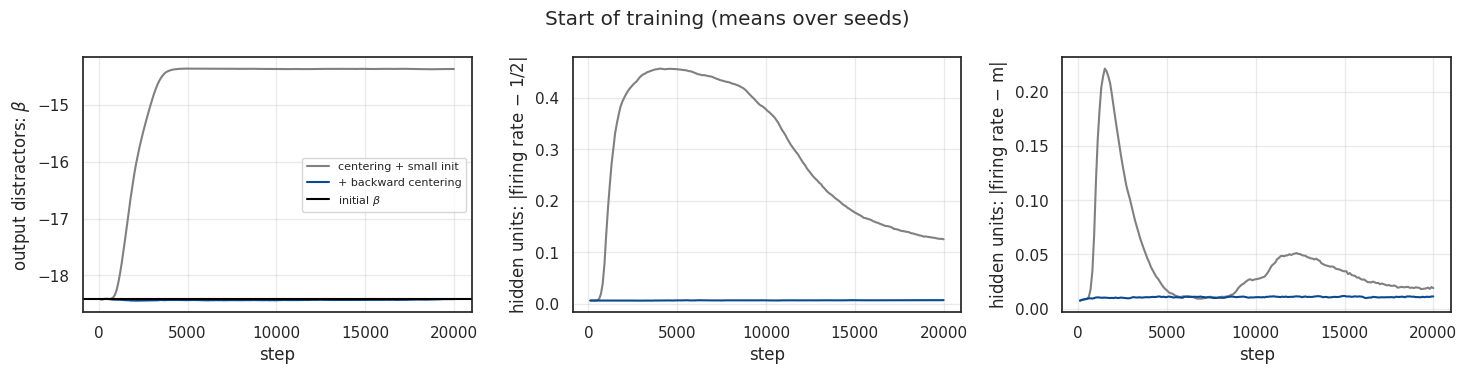

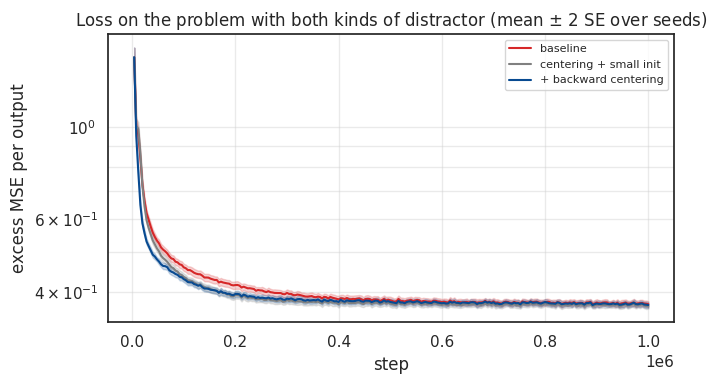

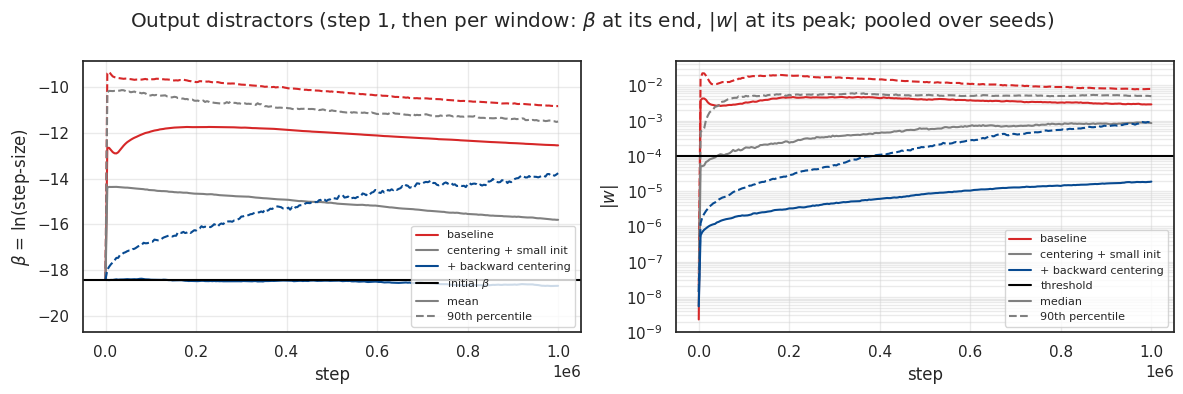

output distractors (initial beta -18.4)
  baseline                 excess MSE 0.3753 (+0.0%) ✓   max |w|: median 4.7e-03 ✗, p90 2.2e-02 ✗   final beta: mean -12.5 ✗, p90 -10.8 ✗
  centering + small init   excess MSE 0.3712 (-1.1%) ✓   max |w|: median 9.0e-04 ✗, p90 6.1e-03 ✗   final beta: mean -15.8 ✗, p90 -11.5 ✗
  + backward centering     excess MSE 0.3738 (-0.4%) ✓   max |w|: median 1.9e-05 ✓, p90 9.4e-04 ✗   final beta: mean -18.7 ✓, p90 -13.8 ✗


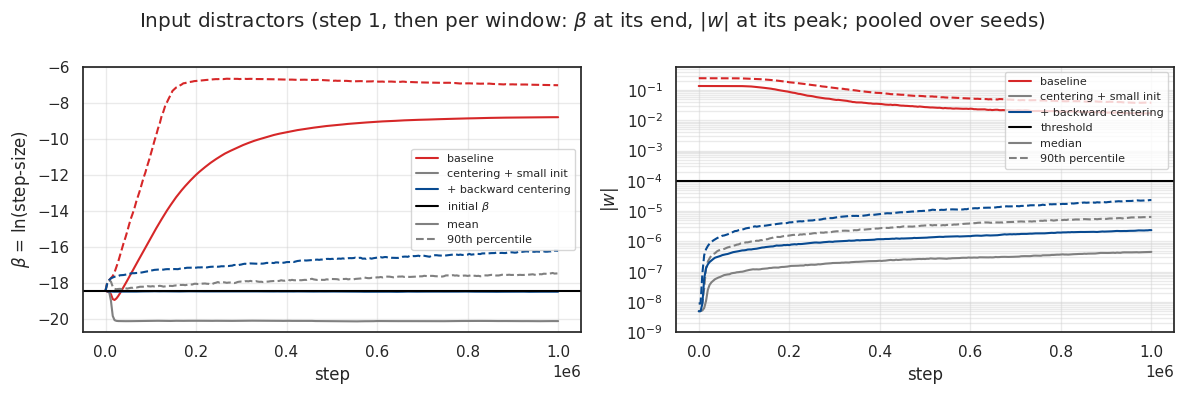

input distractors (initial beta -18.4)
  baseline                 excess MSE 0.3753 (+0.0%) ✓   max |w|: median 1.4e-01 ✗, p90 2.4e-01 ✗   final beta: mean -8.8 ✗, p90 -7.0 ✗
  centering + small init   excess MSE 0.3712 (-1.1%) ✓   max |w|: median 4.5e-07 ✓, p90 6.4e-06 ✓   final beta: mean -20.1 ✓, p90 -17.5 ✗
  + backward centering     excess MSE 0.3738 (-0.4%) ✓   max |w|: median 2.4e-06 ✓, p90 2.3e-05 ✓   final beta: mean -18.5 ✓, p90 -16.2 ✗


In [14]:
both_fixed = {'+ backward centering': Method(**combination, center_backward=True)}
plot_early({**early, **early_dynamics(both_fixed)})

both_fixed_run = run(both_fixed)
runs = {**both_baseline, **both_combination, **both_fixed_run}
plot_loss(runs, 'both')
for kind in DISTRACTOR_LAYER:
    plot_distractors(runs, kind)
    report(runs, kind)

## Distractors against useful weights

The 3c network (centering, small input weights, backward centering; no decay) on the problem with both kinds of
distractor. In each layer, its distractors are compared with its useful connections (the block structure, without
biases): the mean of $\beta$ and the median of $|w|$, with the 5th to 95th percentile shaded, pooled over seeds.

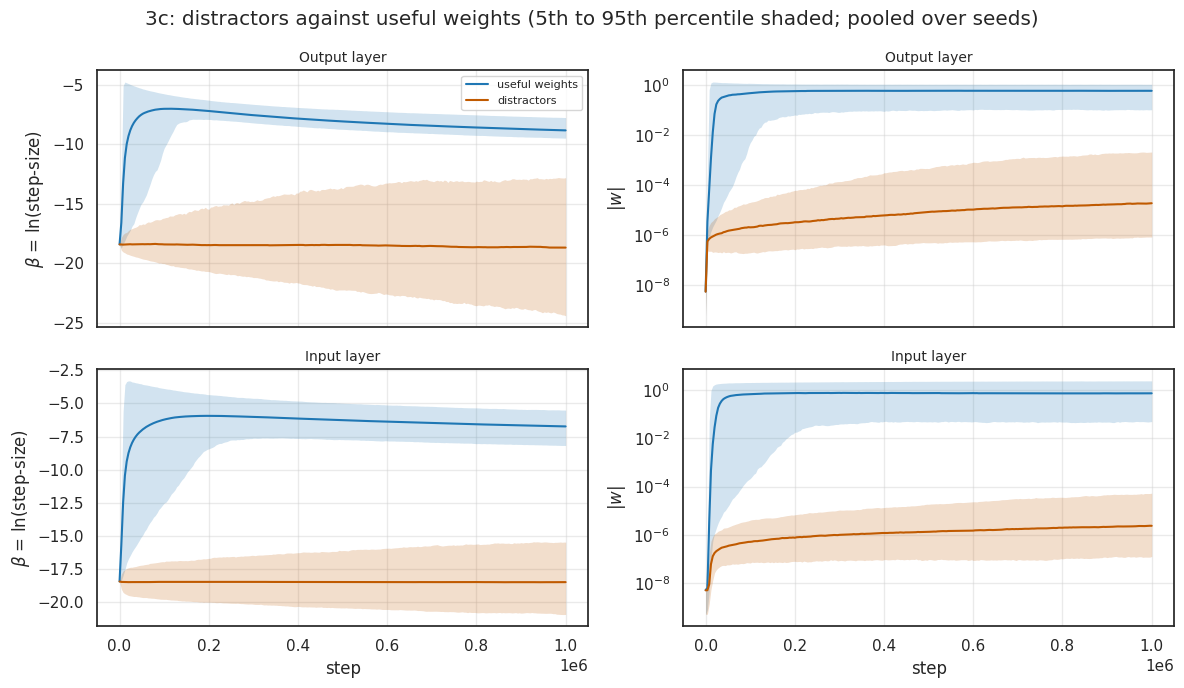

In [15]:
useful_run = run(both_fixed, record=USEFUL)['+ backward centering']   # 3c again, recording the useful weights
groups = {'useful weights': useful_run, 'distractors': both_fixed_run['+ backward centering']}

fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True)
columns = [('beta', '$\\beta$ = ln(step-size)', np.mean, 'linear'), ('w', '$|w|$', np.median, 'log')]
for row, (kind, layer) in zip(axes, DISTRACTOR_LAYER.items()):
    for ax, (quantity, ylabel, center, yscale) in zip(row, columns):
        for (label, res), color in zip(groups.items(), ('#1f77b4', '#c05a00')):
            v = res[layer][quantity].transpose(1, 0, 2).reshape(len(STEPS), -1)     # (step, weight of any seed)
            ax.plot(STEPS, center(v, axis=1), color=color, lw=1.5, label=label)
            ax.fill_between(STEPS, *np.percentile(v, [5, 95], axis=1), color=color, alpha=0.2, lw=0)
        ax.set_yscale(yscale)
        ax.set_title(f'{kind.capitalize()} layer', fontsize=10)
        ax.set_ylabel(ylabel)
        ax.grid(alpha=0.4, which='both')
for ax in axes[1]:
    ax.set_xlabel('step')
axes[0, 0].legend(fontsize=8)
fig.suptitle('3c: distractors against useful weights (5th to 95th percentile shaded; pooled over seeds)')
fig.tight_layout()
plt.show()

<!-- PARKED (Question 4): remove this comment wrapper to show the text.
## Question 4: making every distractor's step-size fall

With backward centering (3c), the output distractors' mean $\beta$ falls, but their 90th percentile stays above the
initial $\beta$, and the input distractors' mean $\beta$ does not fall at all. Each step moves a distractor's $\beta$ by
$\mu\,hg/v$, a random step of fixed size (about $\pm 0.17\mu$) however small its step-size. The only pull down comes from
the distractor's own effect on the error, which is proportional to its $|w|$ and too weak to win within 1M steps. An
input distractor has no pull at all, since a tiny input weight almost never flips its LTU. So the spread of $\beta$
keeps growing, and as a few large step-sizes dominate their average, the mean step-size rises even where the mean of
$\beta$ falls.

How can we make every distractor's step-size fall: its mean, and, given enough time, every percentile?
-->

In [16]:
# PARKED, NOT RUN (Question 4, step-size decay): uncomment this cell and the rest of Question 4 to run it.
# def plot_step_sizes(runs, kind):
#     # The mean of beta next to the mean step-size (the mean of exp(beta)), at the end of each window, pooled over every
#     # distractor of every seed. Anything more than an order of magnitude below the initial step-size is drawn on the floor.
#     layer = DISTRACTOR_LAYER[kind]
#     fig, axes = plt.subplots(1, 2, figsize=(12, 4))
#     panels = [(lambda b: b, 'mean $\\beta$', np.log(INIT_STEP_SIZE), 'initial $\\beta$', 'linear',
#                np.log(INIT_STEP_SIZE / 10)),
#               (np.exp, 'mean step-size', INIT_STEP_SIZE, 'initial step-size', 'log', INIT_STEP_SIZE / 10)]
#     for ax, (transform, ylabel, ref, ref_label, yscale, bottom) in zip(axes, panels):
#         for (label, res), color in zip(runs.items(), colors(runs)):
#             mean = transform(res[layer]['beta']).mean(axis=(0, 2))
#             ax.plot(STEPS, np.maximum(mean, bottom), color=color, lw=1.5, label=label)
#         ax.axhline(ref, color='black', lw=1.5, label=ref_label)
#         ax.set_yscale(yscale)
#         ax.set_ylim(bottom=bottom)
#         ax.set_xlabel('step')
#         ax.set_ylabel(ylabel)
#         ax.grid(alpha=0.4, which='both')
#         ax.legend(fontsize=8)
#     fig.suptitle(f'{kind.capitalize()} distractors (at the end of each window; pooled over seeds)')
#     fig.tight_layout()
#     plt.show()
#
#
# no_decay = {'no decay': both_fixed_run['+ backward centering']}
# for kind in DISTRACTOR_LAYER:
#     plot_step_sizes(no_decay, kind)

<!-- PARKED (Question 4): remove this comment wrapper to show the text.
### 4b. Step-size decay

Every $\beta$ also falls by $\mu\kappa$ per step, so $\beta \leftarrow \beta + \mu\,(hg/v - \kappa)$: a step-size grows
only while its weight's mean $hg/v$ exceeds $\kappa$. This gives every distractor the same steady pull down, which grows
linearly in time while the spread of $\beta$ grows only as its square root, so given enough time every percentile falls;
$\kappa$ sets how soon. The decay applies to every weight, so it also lowers the useful weights' step-sizes once their
mean $hg/v$ drops below $\kappa$. In 3c that happens after about 100k steps, when the network has mostly learned and
their mean $hg/v$ is about 0. Built on 3c (labelled "no decay"), with $\kappa \in \{10^{-3}, 10^{-4}, 10^{-5}\}$.
-->

In [17]:
# PARKED, NOT RUN (Question 4, step-size decay): uncomment this cell and the rest of Question 4 to run it.
# decay = run({f'κ = {k:g}': Method(**combination, center_backward=True, kappa=k) for k in KAPPAS})
#
# runs = {**both_baseline, **no_decay, **decay}
# plot_loss(runs, 'both')
# for kind in DISTRACTOR_LAYER:
#     plot_step_sizes(runs, kind)
#     plot_distractors(runs, kind)
#     report(runs, kind)